# 1. Set up environment

In [1]:
import requests

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from PIL import Image

import IPython.display

# 2. Investigate gene essentiality probability data

## 2.1. Load the data and look at it

In [2]:
def download(url, output_file):
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(output_file, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
    else:
        print(f"Failed to download file. Status code: {response.status_code}")

In [3]:
download("https://plus.figshare.com/ndownloader/files/51064631", "CRISPRGeneDependency.csv")

In [4]:
# Load the dataset into a DataFrame.
df = pd.read_csv("CRISPRGeneDependency.csv")

In [5]:
# Index by screen ID.
df.set_index(df.columns[0], inplace=True)

In [6]:
# Display dataset summary.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1178 entries, ACH-000001 to ACH-003180
Columns: 17916 entries, A1BG (1) to ZZZ3 (26009)
dtypes: float64(17916)
memory usage: 161.0+ MB


In [7]:
# Display some of the records.
df.head()

,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),AADAC (13),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ACH-000001,0.065668,0.015635,0.018194,0.080116,0.027776,0.004321,0.045106,0.053754,0.004370,0.023588,...,0.064946,0.008621,0.005056,0.002127,0.005174,0.161339,0.014115,0.012368,0.006628,0.409237
ACH-000004,0.025267,0.050137,0.050000,0.032089,0.028282,0.091636,0.001559,0.059275,0.003909,0.005066,...,0.121742,0.294430,0.002449,0.009105,0.010306,0.012599,0.304880,0.008154,0.001641,0.021108
ACH-000005,0.076913,0.019836,0.006571,0.011018,0.059735,0.123887,0.006300,0.042264,0.051944,0.016487,...,0.181750,0.211965,0.027067,0.030316,0.020373,0.088972,0.032753,0.030137,0.015747,0.060246
ACH-000007,0.031522,0.047508,0.006059,0.005069,0.016260,0.018866,0.012723,0.090322,0.082053,0.001867,...,0.267304,0.301360,0.017301,0.001322,0.009170,0.034824,0.363788,0.021889,0.178964,0.349167
ACH-000009,0.039600,0.116588,0.016466,0.013633,0.013288,0.086989,0.019045,0.118837,0.021282,0.011256,...,0.335157,0.182601,0.043114,0.002356,0.075201,0.085467,0.652613,0.017909,0.026358,0.271253


## 2.2. Handle missing values

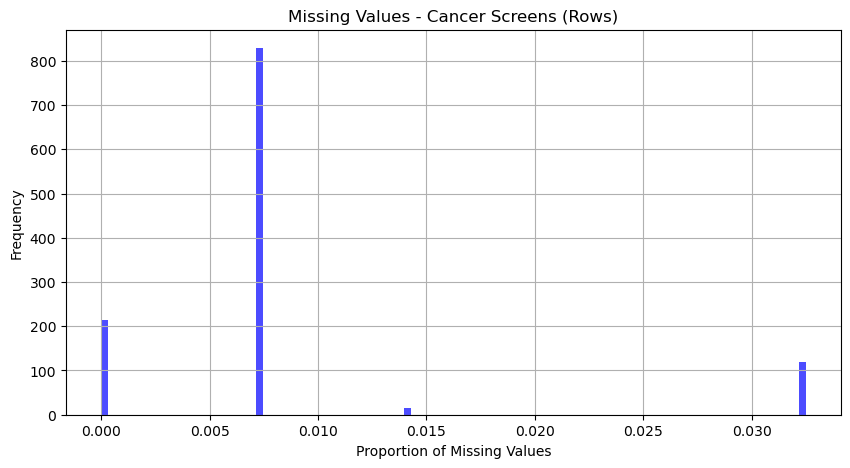

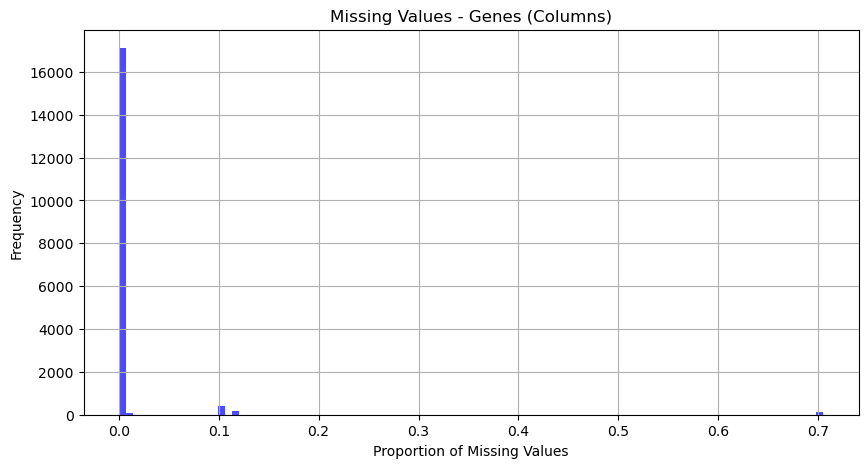

In [8]:
# Calculate the proportion of missing values
missing_by_row = df.isnull().mean(axis=1)
missing_by_column = df.isnull().mean(axis=0)

# Create data for plotting
missing_data = [missing_by_row, missing_by_column]
titles = ["Missing Values - Cancer Screens (Rows)", "Missing Values - Genes (Columns)"]

# Plot histograms
for data, title in zip(missing_data, titles):
    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=100, alpha=0.7, color='blue')
    plt.title(title)
    plt.xlabel("Proportion of Missing Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

Number of dropped genes: 829


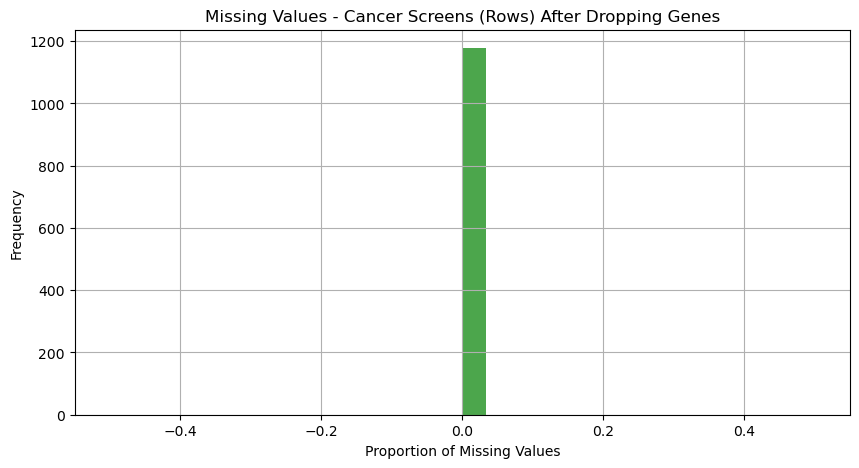

In [9]:
# Calculate the number of columns (genes) to drop
genes_to_drop = df.columns[df.isnull().any()]
num_dropped_genes = len(genes_to_drop)

# Drop columns with at least one missing value
df_no_missing = df.drop(columns=genes_to_drop)

# Print the number of dropped genes
print(f"Number of dropped genes: {num_dropped_genes}")

# Recalculate and plot the histogram for rows
missing_by_row_cleaned = df_no_missing.isnull().mean(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(missing_by_row_cleaned, bins=30, alpha=0.7, color='green')
plt.title("Missing Values - Cancer Screens (Rows) After Dropping Genes")
plt.xlabel("Proportion of Missing Values")
plt.ylabel("Frequency")
plt.grid()
plt.show()

## 2.3. Remove common essential genes

In [10]:
download("https://plus.figshare.com/ndownloader/files/51064916", "CRISPRInferredCommonEssentials.csv")

File downloaded successfully: CRISPRInferredCommonEssentials.csv


In [11]:
# Load the list of column names from the CSV file (ignoring the first row)
column_names = pd.read_csv("CRISPRInferredCommonEssentials.csv", header=None).iloc[1:, 0].tolist()

# Remove columns from df_cleaned that match the names in the file
df_cleaned = df_no_missing.drop(columns=[col for col in df_no_missing.columns if col in column_names])

In [12]:
df_cleaned

,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),AADAC (13),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ACH-000001,0.065668,0.015635,0.018194,0.080116,0.027776,0.004321,0.045106,0.053754,0.004370,0.023588,...,0.064946,0.008621,0.005056,0.002127,0.005174,0.161339,0.014115,0.012368,0.006628,0.409237
ACH-000004,0.025267,0.050137,0.050000,0.032089,0.028282,0.091636,0.001559,0.059275,0.003909,0.005066,...,0.121742,0.294430,0.002449,0.009105,0.010306,0.012599,0.304880,0.008154,0.001641,0.021108
ACH-000005,0.076913,0.019836,0.006571,0.011018,0.059735,0.123887,0.006300,0.042264,0.051944,0.016487,...,0.181750,0.211965,0.027067,0.030316,0.020373,0.088972,0.032753,0.030137,0.015747,0.060246
ACH-000007,0.031522,0.047508,0.006059,0.005069,0.016260,0.018866,0.012723,0.090322,0.082053,0.001867,...,0.267304,0.301360,0.017301,0.001322,0.009170,0.034824,0.363788,0.021889,0.178964,0.349167
ACH-000009,0.039600,0.116588,0.016466,0.013633,0.013288,0.086989,0.019045,0.118837,0.021282,0.011256,...,0.335157,0.182601,0.043114,0.002356,0.075201,0.085467,0.652613,0.017909,0.026358,0.271253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-002926,0.051287,0.047941,0.009162,0.005529,0.057342,0.032345,0.032228,0.099910,0.025682,0.004286,...,0.463674,0.751708,0.010001,0.001116,0.098489,0.024442,0.170922,0.007541,0.073935,0.320988
ACH-002928,0.188160,0.087219,0.062521,0.031245,0.146053,0.046314,0.013510,0.015555,0.141084,0.014670,...,0.045569,0.428342,0.002741,0.011294,0.008005,0.016600,0.011255,0.163807,0.053188,0.040570
ACH-003012,0.062732,0.018869,0.007628,0.002783,0.032499,0.057233,0.016252,0.203198,0.017947,0.004439,...,0.159537,0.719778,0.081715,0.003480,0.025234,0.003909,0.102925,0.021411,0.090717,0.189673


## 2.4. PCA plots

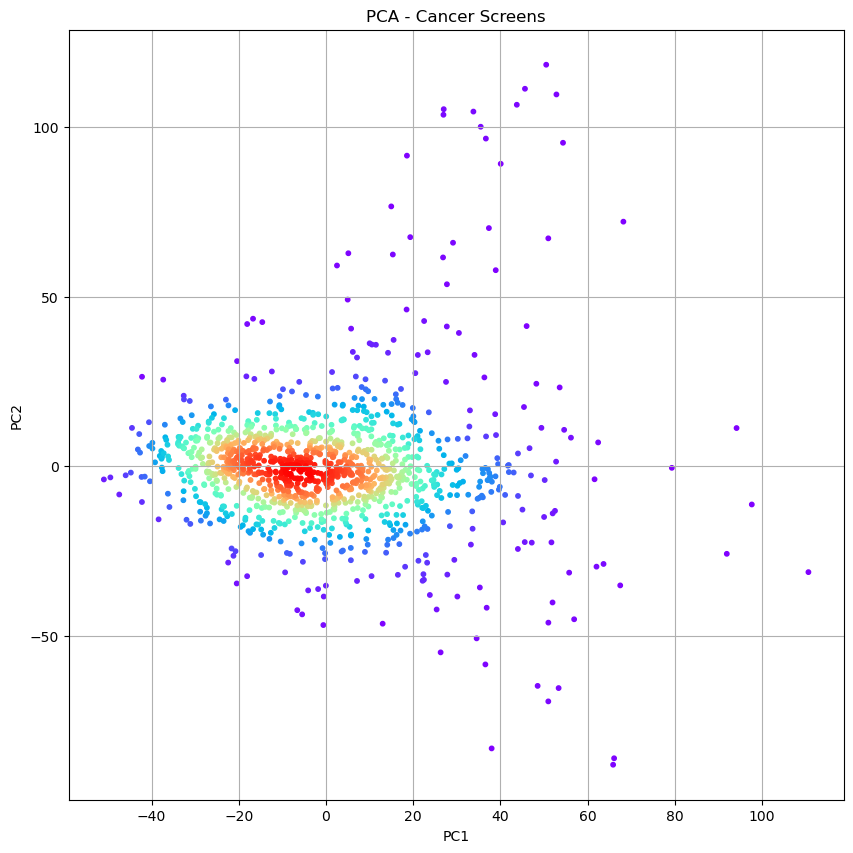

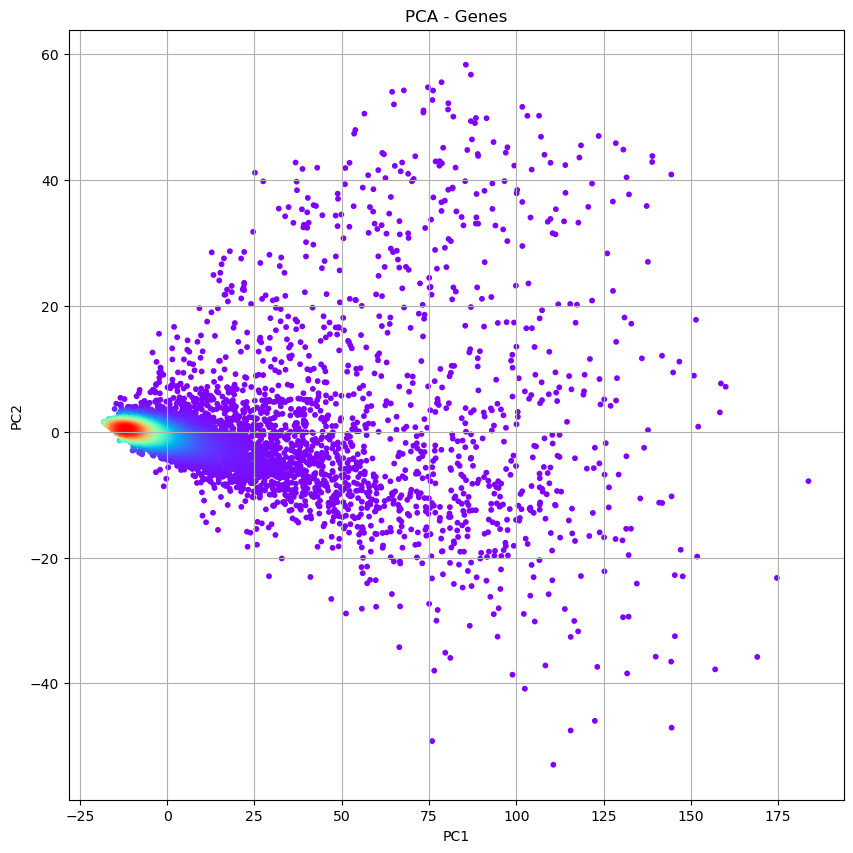

In [13]:
# Function to perform PCA and plot results with density
def plot_pca_density(data, title):
    pca_result = PCA(n_components=2).fit_transform(data)
    x, y = pca_result[:, 0], pca_result[:, 1]
    # Calculate point density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    
    # Sort points by density for better visualization
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    
    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(x, y, c=z, cmap="rainbow", s=10)
    # plt.colorbar(scatter, label="Density")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()
    plt.show()

# Standardize data for rows and columns
scaler = StandardScaler()
data_row = scaler.fit_transform(df_cleaned)
data_col = scaler.fit_transform(df_cleaned.T)

# Titles for plots
titles = ["PCA - Cancer Screens", "PCA - Genes"]

# Loop through data and titles to create density plots
for data, title in zip([data_row, data_col], titles):
    plot_pca_density(data, title)

## 2.5. Plot hierarchically sorted matrix

In [14]:
def hierarchical_sort(df_cleaned):
    # Hierarchical clustering for rows
    linkage_rows = linkage(df_cleaned, method='ward')
    # Hierarchical clustering for columns
    linkage_cols = linkage(df_cleaned.T, method='ward')
    row_order = leaves_list(linkage_rows)
    col_order = leaves_list(linkage_cols)
    return df_cleaned.iloc[row_order, col_order]

In [15]:
# Sort the dataframe according to hierarchical clustering
df_sorted = hierarchical_sort(df_cleaned)

In [16]:
def plot_heatmap(df_sorted, filename, cmap="seismic"):
    # Assuming df_sorted is your pandas dataframe with values between 0 and 1
    data = df_sorted.values

    # Convert normalized data to an array in [0, 255] range
    scaled_data = (data * 255).astype(np.uint8)

    # Use a colormap
    cmap = plt.get_cmap(cmap)
    
    # Apply colormap
    colored_data = cmap(scaled_data)

    # Convert to an RGB image
    img = Image.fromarray((colored_data * 255).astype(np.uint8), mode='RGBA')

    # Save the image
    img.save(filename)
    
    # Display the image. Not on by default to trim down notebook size.
    if display:
        IPython.display.display(IPython.display.Image(filename=filename))

# Heatmap plotting is disabled to cut down on the file size for display.
# plot_heatmap(df_sorted, "heatmap_sorted.png")

## 2.6. Test different probability cut-offs

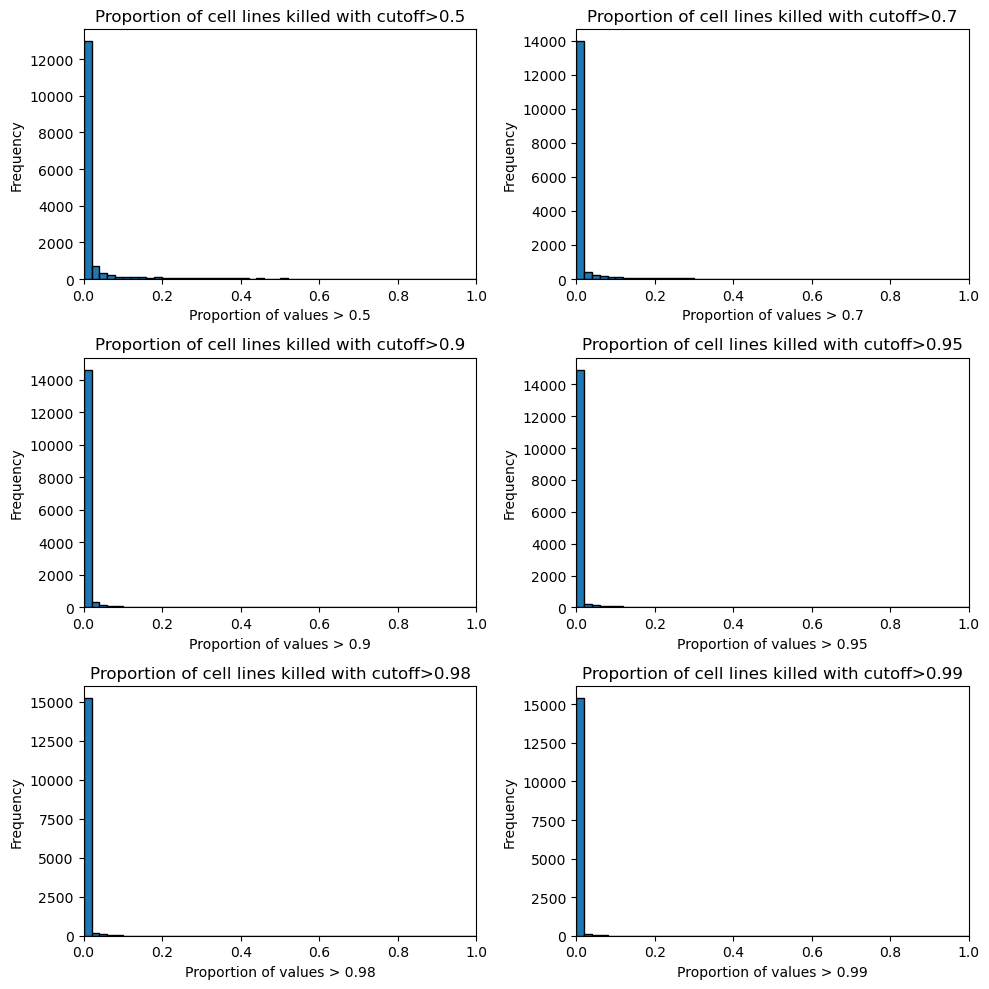

In [17]:
# Proportion of cell lines killed if using given cut-off

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
cutoffs = [0.5, 0.7, 0.9, 0.95, 0.98, 0.99]

for ax, cutoff in zip(axes.flat, cutoffs):
    proportions = (df_cleaned > cutoff).mean()
    ax.hist(proportions, bins=50, edgecolor='k', range=(0, 1))
    ax.set_xlabel(f'Proportion of values > {cutoff}')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Proportion of cell lines killed with cutoff>{cutoff}')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

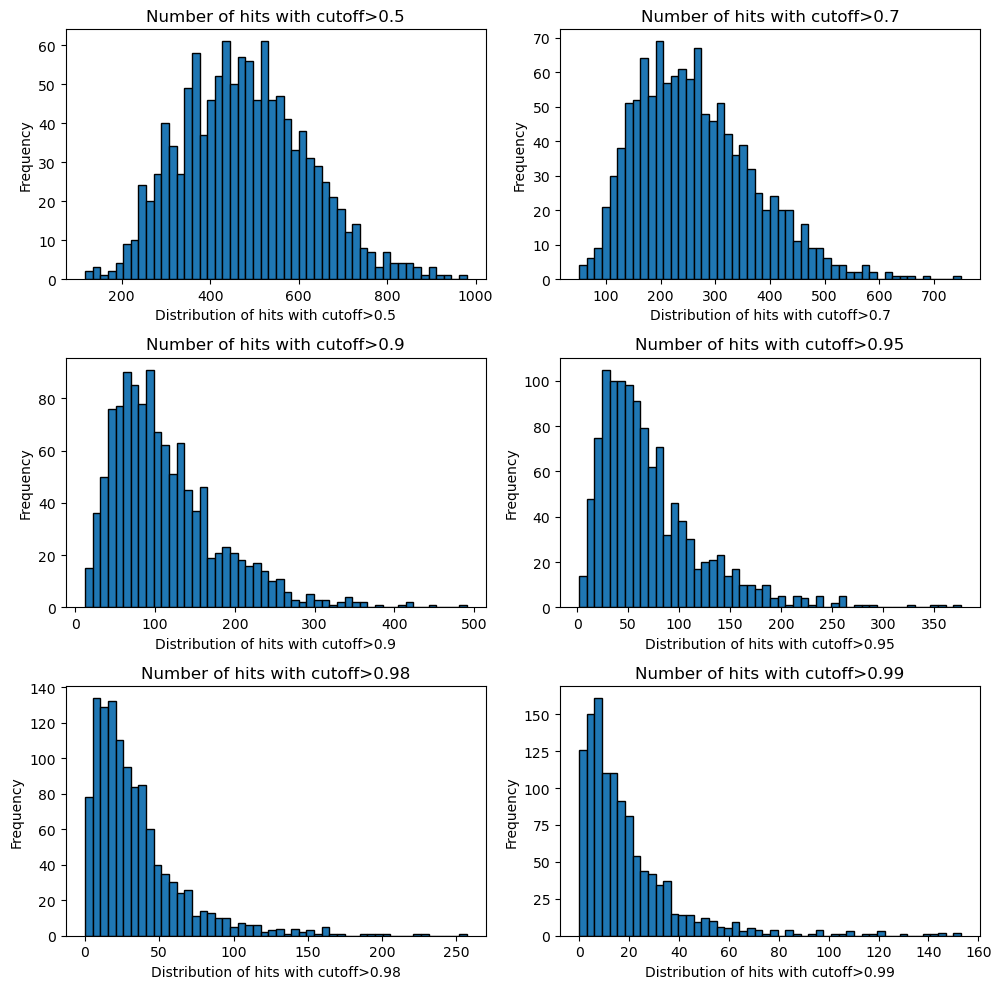

In [18]:
# Number of hits per screen

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

for ax, cutoff in zip(axes.flat, cutoffs):
    hits = (df_cleaned > cutoff).sum(axis=1)
    ax.hist(hits, bins=50, edgecolor='k')
    ax.set_xlabel(f'Distribution of hits with cutoff>{cutoff}')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Number of hits with cutoff>{cutoff}')

plt.tight_layout()
plt.show()

## 2.7. Check values for known essential genes

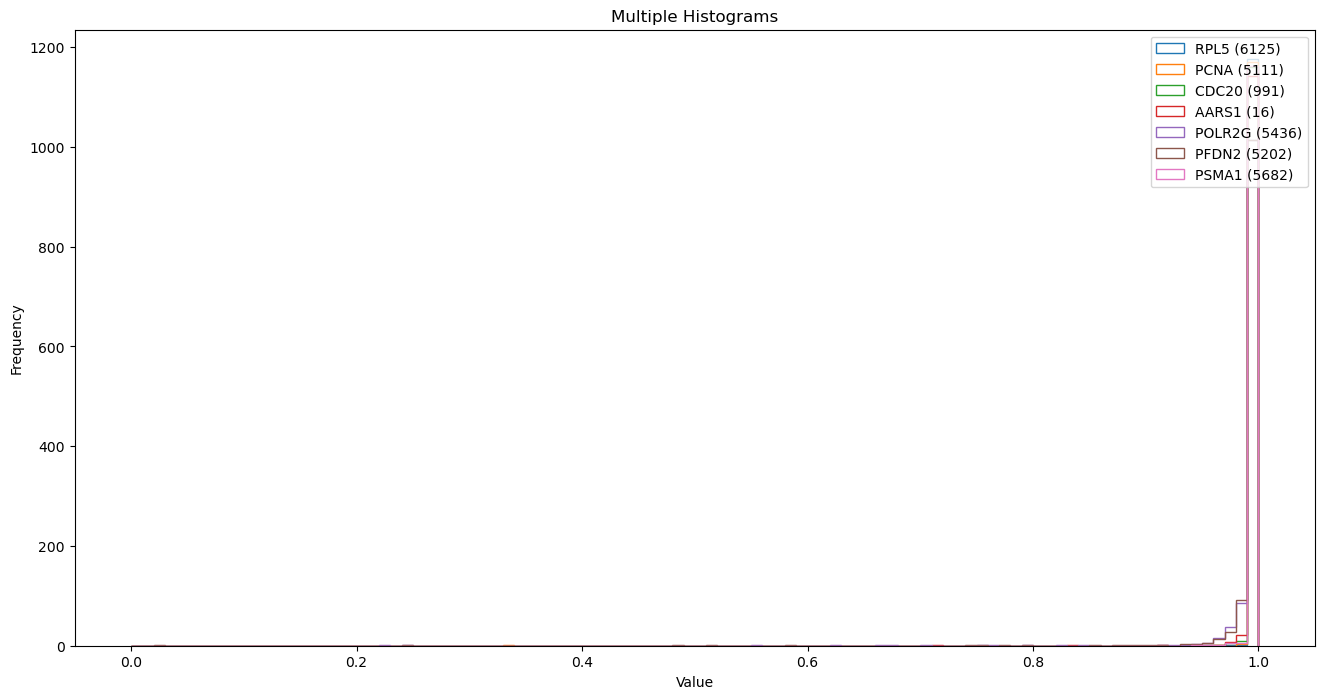

In [19]:
essential_genes = [
    "RPL5 (6125)",      # Ribosomal component, crucial for protein synthesis.
    "PCNA (5111)",      # DNA replication, supports polymerase activity.
    "CDC20 (991)",      # Activator of the anaphase-promoting complex, essential for mitosis.
    "AARS1 (16)",       # Alanyl-tRNA synthetase 1, translation.
    "POLR2G (5436)",    # RNA polymerase II subunit G.
    "PFDN2 (5202)",     # Prefoldin 2, protein folding.
    "PSMA1 (5682)",     # Proteasome.
]

plt.figure(figsize=(16, 8))
for column in essential_genes:
    plt.hist(df_no_missing[column], bins=100, range=(0, 1), histtype='step', label=column)

# Add legend and labels
plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Multiple Histograms')
plt.show()

## 2.8. Re-plot the heatmap with 0.95 cut-off

In [20]:
df_cutoff = (df_sorted > 0.95)
# Heatmap plotting is disabled to cut down on the file size for display.
# plot_heatmap(df_cutoff, "histogram_cutoff.png", cmap="magma")